# UWB Radar | Dataset & Measurement Report
**MobiVital tripod recordings - subject-independent evaluation**

This notebook presents the dataset inventory, fixed cross-validation splits, and measured radar waveforms. Tables and figures are embedded in the executed notebook.

**Data provenance.** Dataset-wide counts are reference values from `docs/CHIA_DU_LIEU.md`. Waveforms are real public MobiVital recordings for development subjects A, C, and F, retrieved from [Zenodo record 15022885](https://zenodo.org/records/15022885). These three recordings illustrate measurements; they do not revalidate the full dataset counts.

**Reading guide:** 1. Inventory | 2. Cross-validation | 3. Final evaluation | 4. Measured waveforms | 5. Verification.
A dash denotes a value that does not apply. No model predictions or test-set scores are generated here.


In [1]:
from pathlib import Path
import hashlib
import json
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from IPython.display import Markdown, display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src/data_splits.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook inside the UWB_RADAR project.")
sys.path.insert(0, str(ROOT)) if str(ROOT) not in sys.path else None
from src.data_splits import DEV_USERS, TEST_USERS, split_plan
plan = split_plan()

MEASUREMENT_DIR = ROOT / "data/measurement_preview"
SELECTED_SUBJECT = "A"
RANGE_BIN = 24  # Fixed illustrative bin; not selected using the reference signal.
SAMPLE_RATE_HZ = 50.0  # Project sampling rate: docs/THAM_CHIEU.md.
SAVE_FIGURES = False

C = {"train": "#176B87", "val": "#E8AA42", "test": "#785DA8",
     "ink": "#213547", "muted": "#66788A", "gt": "#C24A56"}
plt.rcParams.update({"figure.dpi": 120, "font.family": "DejaVu Sans",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelcolor": C["ink"], "text.color": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.16, "axes.axisbelow": True,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "lines.linewidth": 1.5})
table_count = 0

def table(title, headers, rows, note=""):
    global table_count
    table_count += 1
    def fmt(v):
        if v is None:
            return "-"
        if isinstance(v, (int, np.integer)):
            return f"{v:,}"
        return str(v).replace("|", "/").replace("\n", " ")
    lines = [f"### Table {table_count}. {title}", "",
             "| " + " | ".join(headers) + " |",
             "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines += ["| " + " | ".join(fmt(v) for v in row) + " |" for row in rows]
    if note:
        lines += ["", note]
    display(Markdown("\n".join(lines)))

def figure(fig, name):
    if SAVE_FIGURES:
        out = ROOT / "reports/data_visualization/english"
        out.mkdir(parents=True, exist_ok=True)
        fig.savefig(out / (name + ".png"), dpi=200, bbox_inches="tight")
    plt.show()

def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / x.std() if x.std() > 0 else np.zeros_like(x)



## 1. Dataset inventory
The development pool contains eight subjects. Four different subjects are reserved for final testing.
Training-window counts refer to the per-subject `dev_cv` pool at correlation threshold 0.9, history length 200, and forecast length 25.


### Table 1. Subject-level inventory

| Subject | Pool | Sessions | Share | Training windows | Validation fold |
| --- | --- | --- | --- | --- | --- |
| A | Development | 224 | 12.27% | 42,640 | val_AB |
| B | Development | 156 | 8.54% | 39,104 | val_AB |
| C | Development | 211 | 11.56% | 47,996 | val_CE |
| D | Development | 206 | 11.28% | 53,300 | val_DF |
| E | Development | 126 | 6.90% | 25,792 | val_CE |
| F | Development | 102 | 5.59% | 9,256 | val_DF |
| G | Held-out test | 134 | 7.34% | - | - |
| H | Held-out test | 138 | 7.56% | - | - |
| I | Held-out test | 145 | 7.94% | - | - |
| J | Held-out test | 120 | 6.57% | - | - |
| K | Development | 148 | 8.11% | 50,804 | val_KL |
| L | Development | 116 | 6.35% | 23,816 | val_KL |
| TOTAL | 12 subjects | 1,826 | 100.00% | 292,708 | 4 folds |

Source: docs/CHIA_DU_LIEU.md. Counts are documented reference values.

### Table 2. Development and held-out test

| Pool | Subjects | Subject count | Sessions | Share |
| --- | --- | --- | --- | --- |
| Development | A B C D E F K L | 8 | 1,289 | 70.59% |
| Final test | G H I J | 4 | 537 | 29.41% |

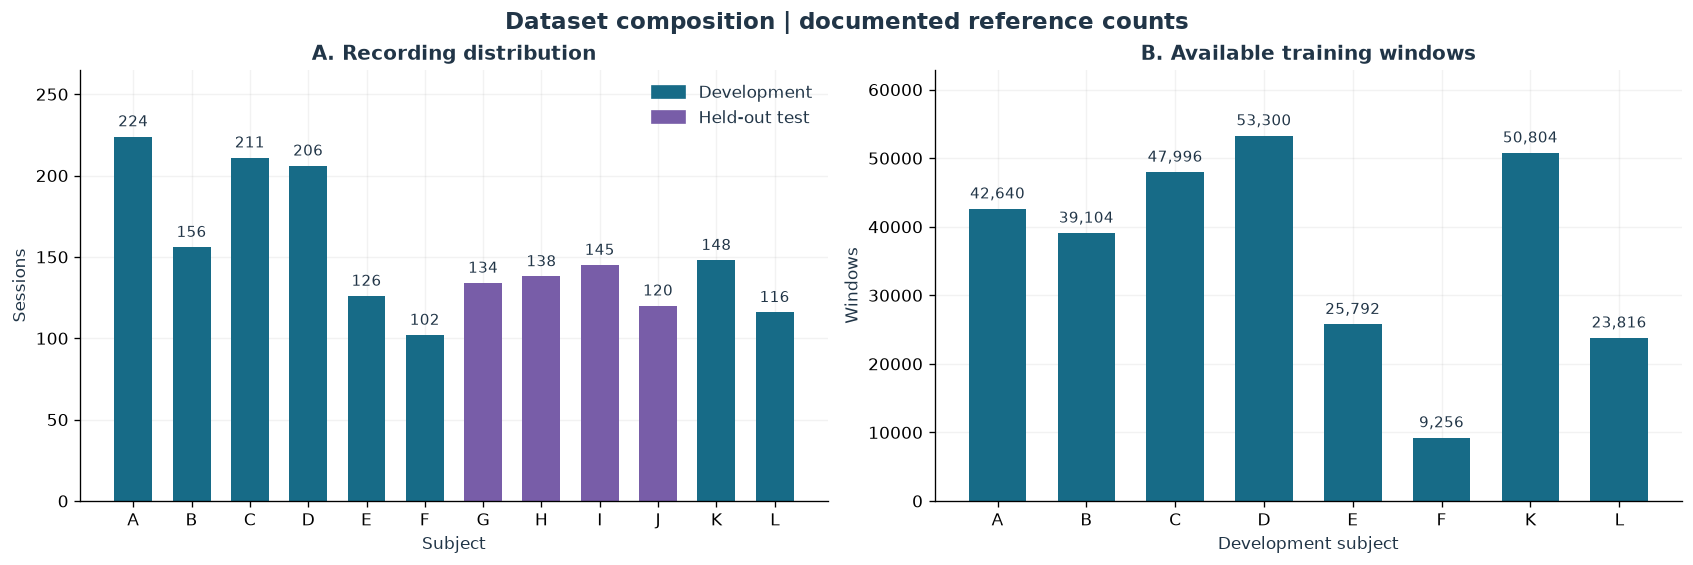

In [2]:
sessions = dict(zip("ABCDEFGHIJKL", [224,156,211,206,126,102,134,138,145,120,148,116]))
windows = dict(zip(DEV_USERS, [42640,39104,47996,53300,25792,9256,50804,23816]))
total_sessions, total_windows = sum(sessions.values()), sum(windows.values())
rows = []
for u in sorted(sessions):
    val = next((f["name"] for f in plan["folds"] if u in f["validation"]), "-")
    rows.append([u, "Development" if u in DEV_USERS else "Held-out test",
                 sessions[u], f"{100*sessions[u]/total_sessions:.2f}%", windows.get(u), val])
rows.append(["TOTAL", "12 subjects", total_sessions, "100.00%", total_windows, "4 folds"])
table("Subject-level inventory", ["Subject", "Pool", "Sessions", "Share", "Training windows", "Validation fold"],
      rows, "Source: docs/CHIA_DU_LIEU.md. Counts are documented reference values.")
table("Development and held-out test", ["Pool", "Subjects", "Subject count", "Sessions", "Share"],
      [[label, " ".join(group), len(group), sum(sessions[u] for u in group),
        f"{100*sum(sessions[u] for u in group)/total_sessions:.2f}%"]
       for label, group in [("Development", DEV_USERS), ("Final test", TEST_USERS)]])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), constrained_layout=True)
users = sorted(sessions)
b = axes[0].bar(users, [sessions[u] for u in users],
                color=[C["test"] if u in TEST_USERS else C["train"] for u in users], width=.65)
axes[0].bar_label(b, padding=4, fontsize=9)
axes[0].set(title="A. Recording distribution", xlabel="Subject", ylabel="Sessions", ylim=(0, 265))
axes[0].legend(handles=[Patch(color=C["train"], label="Development"), Patch(color=C["test"], label="Held-out test")])
b = axes[1].bar(DEV_USERS, [windows[u] for u in DEV_USERS], color=C["train"], width=.65)
axes[1].bar_label(b, labels=[f"{windows[u]:,}" for u in DEV_USERS], padding=4, fontsize=9)
axes[1].set(title="B. Available training windows", xlabel="Development subject", ylabel="Windows",
            ylim=(0, max(windows.values())*1.18))
fig.suptitle("Dataset composition | documented reference counts", fontsize=14, fontweight="bold")
figure(fig, "01_inventory")


## 2. Fixed cross-validation protocol
Each fold trains on six subjects and validates on two previously unseen subjects. All sessions belonging to one subject remain together. GHIJ is held out throughout model selection.

Validation uses complete radar recordings. Ground-truth-filtered windows are used for training only.


### Table 3. Cross-validation summary

| Fold | Training subjects | Validation subjects | Train sessions | Val sessions | Train windows | Val share of dev |
| --- | --- | --- | --- | --- | --- | --- |
| val_AB | C D E F K L | A B | 909 | 380 | 210,964 | 29.48% |
| val_CE | A B D F K L | C E | 952 | 337 | 218,920 | 26.14% |
| val_DF | A B C E K L | D F | 981 | 308 | 230,152 | 23.89% |
| val_KL | A B C D E F | K L | 1,025 | 264 | 218,088 | 20.48% |

Do not sum training sessions across folds as unique recordings: each development subject trains in three folds.

### Table 4. Subject assignment across stages

| Subject | Sessions | val_AB | val_CE | val_DF | val_KL | Final stage |
| --- | --- | --- | --- | --- | --- | --- |
| A | 224 | Validation | Train | Train | Train | Train |
| B | 156 | Validation | Train | Train | Train | Train |
| C | 211 | Train | Validation | Train | Train | Train |
| D | 206 | Train | Train | Validation | Train | Train |
| E | 126 | Train | Validation | Train | Train | Train |
| F | 102 | Train | Train | Validation | Train | Train |
| G | 134 | Held out | Held out | Held out | Held out | Test |
| H | 138 | Held out | Held out | Held out | Held out | Test |
| I | 145 | Held out | Held out | Held out | Held out | Test |
| J | 120 | Held out | Held out | Held out | Held out | Test |
| K | 148 | Train | Train | Train | Validation | Train |
| L | 116 | Train | Train | Train | Validation | Train |

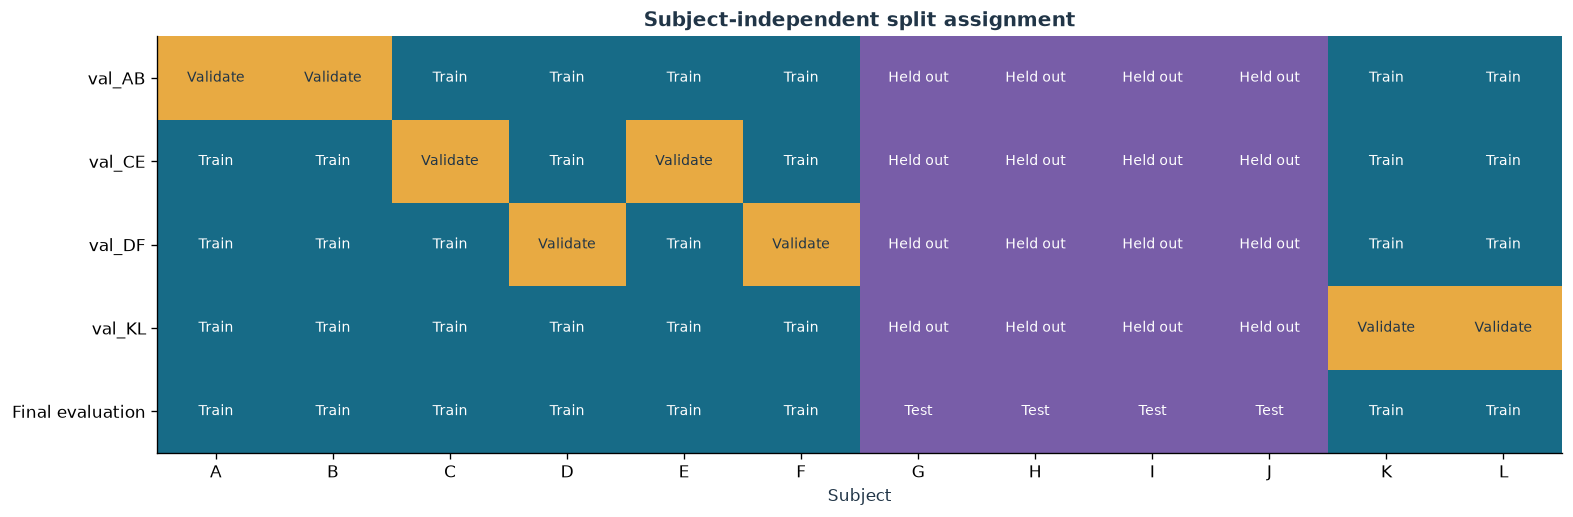

In [3]:
fold_rows = []
for f in plan["folds"]:
    nt = sum(sessions[u] for u in f["train"])
    nv = sum(sessions[u] for u in f["validation"])
    fold_rows.append([f["name"], " ".join(f["train"]), " ".join(f["validation"]),
                      nt, nv, sum(windows[u] for u in f["train"]), f"{100*nv/(nt+nv):.2f}%"])
table("Cross-validation summary",
      ["Fold", "Training subjects", "Validation subjects", "Train sessions", "Val sessions", "Train windows", "Val share of dev"],
      fold_rows, "Do not sum training sessions across folds as unique recordings: each development subject trains in three folds.")
table("Subject assignment across stages",
      ["Subject", "Sessions"] + [f["name"] for f in plan["folds"]] + ["Final stage"],
      [[u, sessions[u]] + ["Held out" if u in TEST_USERS else "Validation" if u in f["validation"] else "Train"
                            for f in plan["folds"]] + ["Train" if u in DEV_USERS else "Test"]
       for u in sorted(sessions)])
matrix = [[2 if u in TEST_USERS else 1 if u in f["validation"] else 0 for u in users] for f in plan["folds"]]
matrix.append([2 if u in TEST_USERS else 0 for u in users])
fig, ax = plt.subplots(figsize=(13, 4.2), constrained_layout=True)
ax.grid(False)
ax.imshow(matrix, cmap=ListedColormap([C["train"], C["val"], C["test"]]), vmin=0, vmax=2, aspect="auto")
ax.set_xticks(range(12), users)
ax.set_yticks(range(5), [f["name"] for f in plan["folds"]] + ["Final evaluation"])
for r, values in enumerate(matrix):
    for c, role in enumerate(values):
        ax.text(c, r, ["Train", "Validate", "Held out" if r < 4 else "Test"][role],
                ha="center", va="center", fontsize=8.5, color=C["ink"] if role==1 else "white")
ax.set(title="Subject-independent split assignment", xlabel="Subject")
figure(fig, "02_assignment")


### Table 5. Detailed allocation: val_AB

| Subject / total | Role / subjects | Sessions | Windows used for training |
| --- | --- | --- | --- |
| A | Validation | 224 | - |
| B | Validation | 156 | - |
| C | Train | 211 | 47,996 |
| D | Train | 206 | 53,300 |
| E | Train | 126 | 25,792 |
| F | Train | 102 | 9,256 |
| K | Train | 148 | 50,804 |
| L | Train | 116 | 23,816 |
| TRAIN TOTAL | C D E F K L | 909 | 210,964 |
| VALIDATION TOTAL | A B | 380 | - |
| HELD-OUT TEST | G H I J | 537 | - |

A dash for validation windows means not used; it does not mean zero available windows.

### Table 6. Detailed allocation: val_CE

| Subject / total | Role / subjects | Sessions | Windows used for training |
| --- | --- | --- | --- |
| A | Train | 224 | 42,640 |
| B | Train | 156 | 39,104 |
| C | Validation | 211 | - |
| D | Train | 206 | 53,300 |
| E | Validation | 126 | - |
| F | Train | 102 | 9,256 |
| K | Train | 148 | 50,804 |
| L | Train | 116 | 23,816 |
| TRAIN TOTAL | A B D F K L | 952 | 218,920 |
| VALIDATION TOTAL | C E | 337 | - |
| HELD-OUT TEST | G H I J | 537 | - |

A dash for validation windows means not used; it does not mean zero available windows.

### Table 7. Detailed allocation: val_DF

| Subject / total | Role / subjects | Sessions | Windows used for training |
| --- | --- | --- | --- |
| A | Train | 224 | 42,640 |
| B | Train | 156 | 39,104 |
| C | Train | 211 | 47,996 |
| D | Validation | 206 | - |
| E | Train | 126 | 25,792 |
| F | Validation | 102 | - |
| K | Train | 148 | 50,804 |
| L | Train | 116 | 23,816 |
| TRAIN TOTAL | A B C E K L | 981 | 230,152 |
| VALIDATION TOTAL | D F | 308 | - |
| HELD-OUT TEST | G H I J | 537 | - |

A dash for validation windows means not used; it does not mean zero available windows.

### Table 8. Detailed allocation: val_KL

| Subject / total | Role / subjects | Sessions | Windows used for training |
| --- | --- | --- | --- |
| A | Train | 224 | 42,640 |
| B | Train | 156 | 39,104 |
| C | Train | 211 | 47,996 |
| D | Train | 206 | 53,300 |
| E | Train | 126 | 25,792 |
| F | Train | 102 | 9,256 |
| K | Validation | 148 | - |
| L | Validation | 116 | - |
| TRAIN TOTAL | A B C D E F | 1,025 | 218,088 |
| VALIDATION TOTAL | K L | 264 | - |
| HELD-OUT TEST | G H I J | 537 | - |

A dash for validation windows means not used; it does not mean zero available windows.

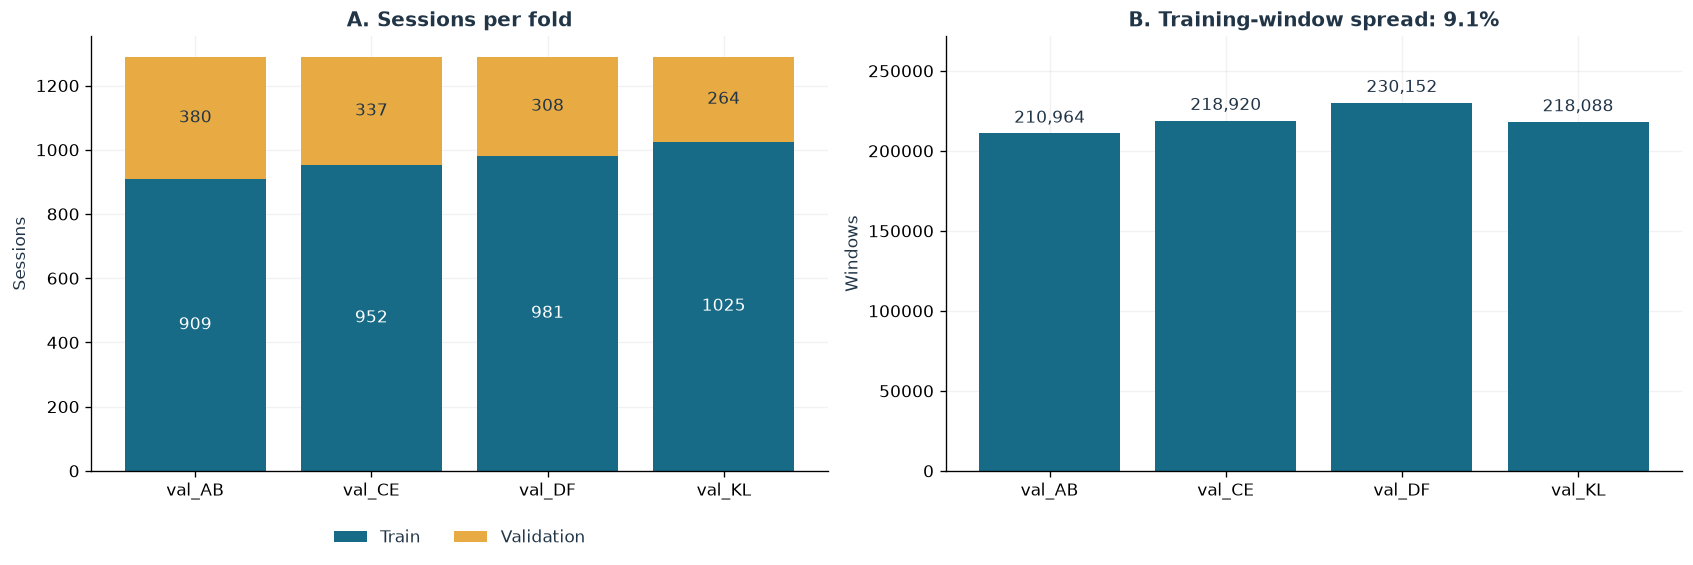

In [4]:
for f in plan["folds"]:
    rows = [[u, "Train" if u in f["train"] else "Validation", sessions[u],
             windows[u] if u in f["train"] else None] for u in DEV_USERS]
    rows += [["TRAIN TOTAL", " ".join(f["train"]), sum(sessions[u] for u in f["train"]),
              sum(windows[u] for u in f["train"])],
             ["VALIDATION TOTAL", " ".join(f["validation"]), sum(sessions[u] for u in f["validation"]), None],
             ["HELD-OUT TEST", " ".join(TEST_USERS), sum(sessions[u] for u in TEST_USERS), None]]
    table("Detailed allocation: " + f["name"], ["Subject / total", "Role / subjects", "Sessions", "Windows used for training"],
          rows, "A dash for validation windows means not used; it does not mean zero available windows.")

names = [f["name"] for f in plan["folds"]]
nt = [sum(sessions[u] for u in f["train"]) for f in plan["folds"]]
nv = [sum(sessions[u] for u in f["validation"]) for f in plan["folds"]]
nw = [sum(windows[u] for u in f["train"]) for f in plan["folds"]]
spread = 100*(max(nw)-min(nw))/min(nw)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), constrained_layout=True)
a = axes[0].bar(names, nt, color=C["train"], label="Train")
b = axes[0].bar(names, nv, bottom=nt, color=C["val"], label="Validation")
axes[0].bar_label(a, label_type="center", color="white")
axes[0].bar_label(b, label_type="center")
axes[0].set(title="A. Sessions per fold", ylabel="Sessions")
axes[0].legend(loc="upper center", bbox_to_anchor=(.5, -.1), ncol=2)
b = axes[1].bar(names, nw, color=C["train"])
axes[1].bar_label(b, labels=[f"{n:,}" for n in nw], padding=4)
axes[1].set(title=f"B. Training-window spread: {spread:.1f}%", ylabel="Windows", ylim=(0,max(nw)*1.18))
figure(fig, "03_fold_balance")


## 3. Final evaluation and inference
Choose the configuration using mean validation Pearson correlation across subjects and folds. Then retrain on all development subjects and evaluate on GHIJ.

Inference is the model's operation on a recording, not a fourth data partition. The current pipeline selects a radar waveform from a complete session; it does not directly output breaths per minute or implement streaming.


In [5]:
table("Final-stage allocation", ["Stage", "Subjects", "Subject count", "Sessions", "Purpose"], [
    ["Final training", " ".join(DEV_USERS), 8, sum(sessions[u] for u in DEV_USERS), "Refit the configuration selected by CV"],
    ["Final testing", " ".join(TEST_USERS), 4, sum(sessions[u] for u in TEST_USERS), "Evaluate after configuration selection"],
    ["Deployment inference", "New subjects", None, None, "Select a waveform using radar only"]])
table("Processing and evaluation settings", ["Setting", "Training", "Validation / test / inference"], [
    ["Recording shape", "1,500 samples x 120 bins", "1,500 samples x 120 bins"],
    ["History / forecast", "200 / 25 samples", "200 / 25 samples"],
    ["Candidate bins", "20 through 28", "0 through 119"],
    ["Transforms", "abs, real, imag, phase", "abs, phase"],
    ["Ground truth", "Window filtering: corr > 0.9", "Scoring only, after channel selection"],
    ["Windows per candidate", "52", "52 for each retained candidate"],
    ["Subject score", None, "Mean session Pearson correlation"],
    ["Fold score", None, "Mean of the two validation subject scores"],
    ["CV score", None, "Mean of four fold scores"],
    ["Evaluation seeds", "0, 1, 2", "Report individual seeds and mean +/- std"]])



### Table 9. Final-stage allocation

| Stage | Subjects | Subject count | Sessions | Purpose |
| --- | --- | --- | --- | --- |
| Final training | A B C D E F K L | 8 | 1,289 | Refit the configuration selected by CV |
| Final testing | G H I J | 4 | 537 | Evaluate after configuration selection |
| Deployment inference | New subjects | - | - | Select a waveform using radar only |

### Table 10. Processing and evaluation settings

| Setting | Training | Validation / test / inference |
| --- | --- | --- |
| Recording shape | 1,500 samples x 120 bins | 1,500 samples x 120 bins |
| History / forecast | 200 / 25 samples | 200 / 25 samples |
| Candidate bins | 20 through 28 | 0 through 119 |
| Transforms | abs, real, imag, phase | abs, phase |
| Ground truth | Window filtering: corr > 0.9 | Scoring only, after channel selection |
| Windows per candidate | 52 | 52 for each retained candidate |
| Subject score | - | Mean session Pearson correlation |
| Fold score | - | Mean of the two validation subject scores |
| CV score | - | Mean of four fold scores |
| Evaluation seeds | 0, 1, 2 | Report individual seeds and mean +/- std |

## 4. Recorded radar waveforms
Three recordings were downloaded from the public archive using HTTP byte ranges. Archive CRCs are checked during extraction; the file hashes and original member paths are saved in `data/measurement_preview/provenance.json`.

The first alphabetically named complete 1,500-sample recording for each subject A, C, and F is used; recordings and bin 24 were not chosen by ground-truth correlation.

**Signal definitions:** I and Q are the measured real and imaginary radar components. Magnitude is `abs(I + jQ)`. Unwrapped phase is used only as a visualization transform. The belt signal is the respiration reference. Amplitudes use arbitrary sensor units; the time axis uses the project's configured 50 Hz rate, not recovered timestamps.

To reproduce on another machine, run `python scripts/download_measurement_preview.py` before **Run All**. The saved notebook already contains the measured-waveform outputs.


In [6]:
manifest_path = MEASUREMENT_DIR / "provenance.json"
if not manifest_path.is_file():
    raise FileNotFoundError("Run python scripts/download_measurement_preview.py to retrieve measured recordings.")
provenance = json.loads(manifest_path.read_text(encoding="utf-8"))
recordings = {}
for item in provenance:
    p = MEASUREMENT_DIR / item["local_file"]
    if hashlib.sha256(p.read_bytes()).hexdigest() != item["sha256"]:
        raise ValueError("Measurement checksum mismatch: " + p.name)
    values = np.loadtxt(p, delimiter=",", dtype=np.float32)
    if values.ndim != 2 or values.shape[0] != 1500 or values.shape[1] < 254:
        raise ValueError(f"Unexpected recording shape: {p.name}: {values.shape}")
    radar = values[:,12:132] + 1j*values[:,132:252]
    gt_raw = values[:,-2].copy()
    if not np.isfinite(radar).all() or not np.isfinite(gt_raw).all():
        raise ValueError("Non-finite measured samples: " + p.name)
    recordings[item["user"]] = dict(radar=radar, gt=gt_raw, name=p.name, columns=values.shape[1])
table("Measurement provenance", ["Subject", "Source recording", "Samples", "Radar bins", "SHA-256 (prefix)"],
      [[u, recordings[u]["name"], 1500, 120,
        next(x["sha256"][:16] for x in provenance if x["user"]==u)] for u in recordings],
      "Source: https://zenodo.org/records/15022885. The full hashes are retained in provenance.json.")
if SELECTED_SUBJECT not in recordings or not 0 <= RANGE_BIN < 120:
    raise ValueError("Select an available development subject and a bin from 0 to 119.")
record = recordings[SELECTED_SUBJECT]
radar, gt = record["radar"], record["gt"]
time_s = np.arange(len(gt))/SAMPLE_RATE_HZ
iq = radar[:,RANGE_BIN]
magnitude = np.abs(iq)
phase = np.unwrap(np.angle(iq))
signals = {"I (a.u.)": iq.real, "Q (a.u.)": iq.imag, "Magnitude (a.u.)": magnitude,
           "Unwrapped phase (rad)": phase, "Respiration belt (a.u.)": gt}
table("Measured signal statistics", ["Signal", "Minimum", "Maximum", "Mean", "Std (population)", "RMS"],
      [[name] + [f"{v:.6g}" for v in [x.min(),x.max(),x.mean(),x.std(),np.sqrt(np.mean(x.astype(float)**2))]]
       for name,x in signals.items()], f"Subject {SELECTED_SUBJECT}, range bin {RANGE_BIN}. Statistics use all 1,500 measured samples.")
table("Measured sample values", ["Sample", "Time (s)", "I", "Q", "Magnitude", "Phase (rad)", "Belt reference"],
      [[i,f"{time_s[i]:.2f}"] + [f"{x[i]:.6g}" for x in signals.values()] for i in range(10)],
      "First 10 samples of the selected recording. Values are measurements and derived transforms, not predictions.")



### Table 11. Measurement provenance

| Subject | Source recording | Samples | Radar bins | SHA-256 (prefix) |
| --- | --- | --- | --- | --- |
| A | 240502_userA_tripod_01_0.csv | 1,500 | 120 | ba1ece79a3cbd6f1 |
| C | 240411_userC_tripod_01_0.csv | 1,500 | 120 | e18a609d0c62134d |
| F | 231128_userF_tripod_01_1.csv | 1,500 | 120 | 5e06e2c02019b98d |

Source: https://zenodo.org/records/15022885. The full hashes are retained in provenance.json.

### Table 12. Measured signal statistics

| Signal | Minimum | Maximum | Mean | Std (population) | RMS |
| --- | --- | --- | --- | --- | --- |
| I (a.u.) | -0.00634426 | -0.00484981 | -0.00584163 | 0.000318193 | 0.00585029 |
| Q (a.u.) | -0.0026355 | 0.00183229 | 1.61865e-05 | 0.00100243 | 0.00100256 |
| Magnitude (a.u.) | 0.00518124 | 0.00647299 | 0.00592892 | 0.000280863 | 0.00593557 |
| Unwrapped phase (rad) | 2.84148 | 3.62803 | 3.14527 | 0.173427 | 3.15005 |
| Respiration belt (a.u.) | 2330 | 3204 | 2581.11 | 178.992 | 2587.31 |

Subject A, range bin 24. Statistics use all 1,500 measured samples.

### Table 13. Measured sample values

| Sample | Time (s) | I | Q | Magnitude | Phase (rad) | Belt reference |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | 0.00 | -0.00608181 | 0.00173378 | 0.00632411 | 2.86388 | 2364 |
| 1 | 0.02 | -0.00605575 | 0.00171268 | 0.00629328 | 2.86597 | 2362 |
| 2 | 0.04 | -0.00606141 | 0.00170848 | 0.00629759 | 2.86686 | 2362 |
| 3 | 0.06 | -0.00607331 | 0.00164192 | 0.00629135 | 2.87755 | 2362 |
| 4 | 0.08 | -0.00607438 | 0.00157446 | 0.00627512 | 2.88798 | 2361 |
| 5 | 0.10 | -0.00608095 | 0.00151293 | 0.00626633 | 2.89774 | 2360 |
| 6 | 0.12 | -0.00607904 | 0.00137959 | 0.00623362 | 2.91843 | 2357 |
| 7 | 0.14 | -0.00607273 | 0.001331 | 0.00621688 | 2.92583 | 2352 |
| 8 | 0.16 | -0.00605957 | 0.0013204 | 0.00620176 | 2.92704 | 2347 |
| 9 | 0.18 | -0.0060615 | 0.00128111 | 0.0061954 | 2.93331 | 2342 |

First 10 samples of the selected recording. Values are measurements and derived transforms, not predictions.

### 4.1. Radar range profile
The overview is shown separately from the time-domain traces. The dashed line marks the fixed illustrative range bin. Each component below has its own figure, title, and units.

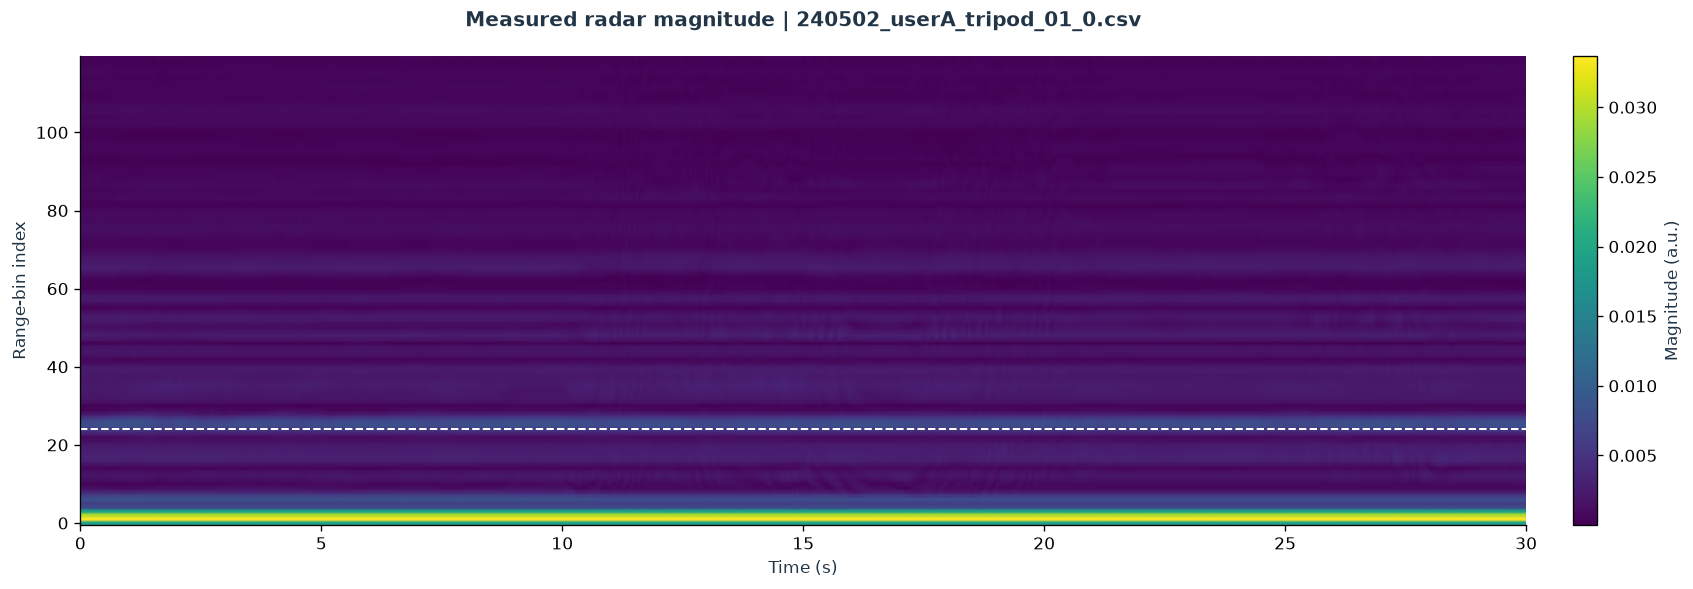

In [7]:
fig, ax = plt.subplots(figsize=(14, 4.8), layout="constrained")
heat = ax.imshow(np.abs(radar).T, origin="lower", aspect="auto",
                 extent=[0, len(gt)/SAMPLE_RATE_HZ, -.5, 119.5], cmap="viridis")
ax.axhline(RANGE_BIN, color="white", ls="--", lw=1.2)
ax.set(title=f"Measured radar magnitude | {record['name']}",
       xlabel="Time (s)", ylabel="Range-bin index")
ax.set_title(ax.get_title(), pad=18)
ax.grid(False)
fig.colorbar(heat, ax=ax, label="Magnitude (a.u.)", pad=.025)
figure(fig, "04a_radar_heatmap")

### 4.2. In-phase component (I)
I is the real component of the complex radar measurement at the selected bin. This trace uses measured sensor units; no standardization is applied.

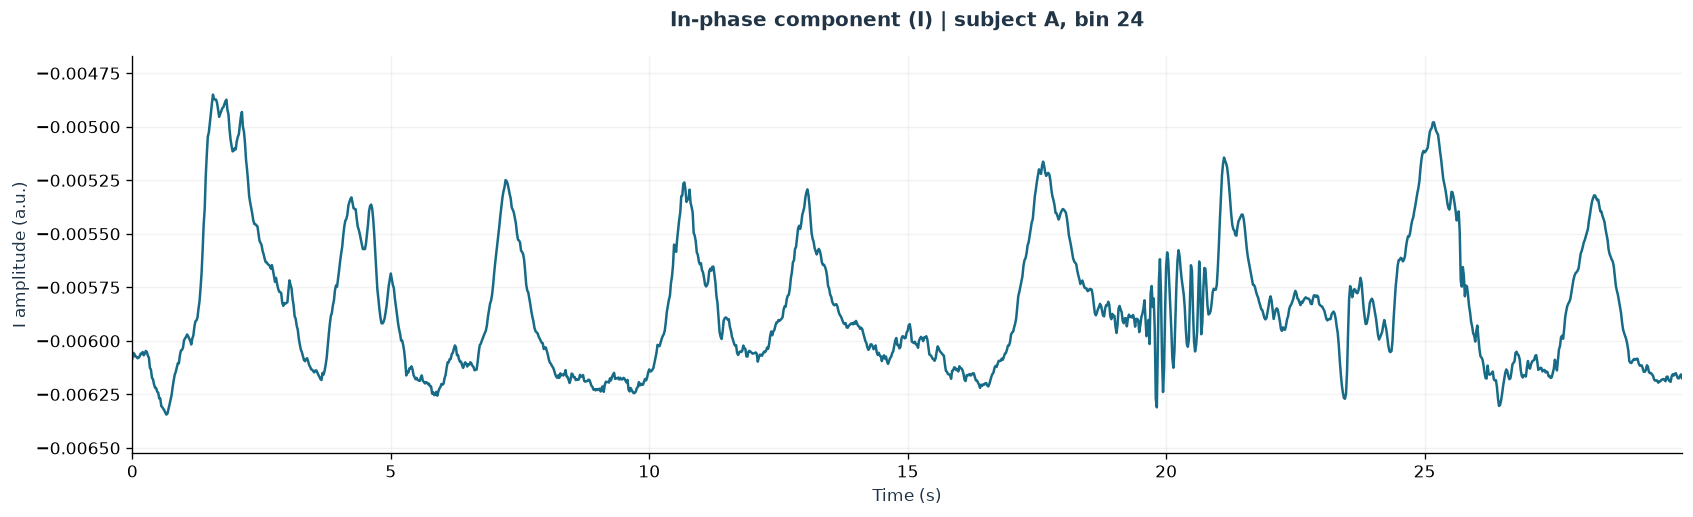

In [8]:
fig, ax = plt.subplots(figsize=(14, 4.2), layout="constrained")
ax.plot(time_s, iq.real, color=C["train"])
ax.set(title=f"In-phase component (I) | subject {SELECTED_SUBJECT}, bin {RANGE_BIN}",
       xlabel="Time (s)", ylabel="I amplitude (a.u.)")
ax.set_title(ax.get_title(), pad=18)
ax.margins(x=0, y=.12)
figure(fig, "04b_in_phase")

### 4.3. Quadrature component (Q)
Q is the imaginary component of the same complex measurement. Its vertical axis is fitted independently from the I figure; compare the numerical axis values when comparing amplitudes.

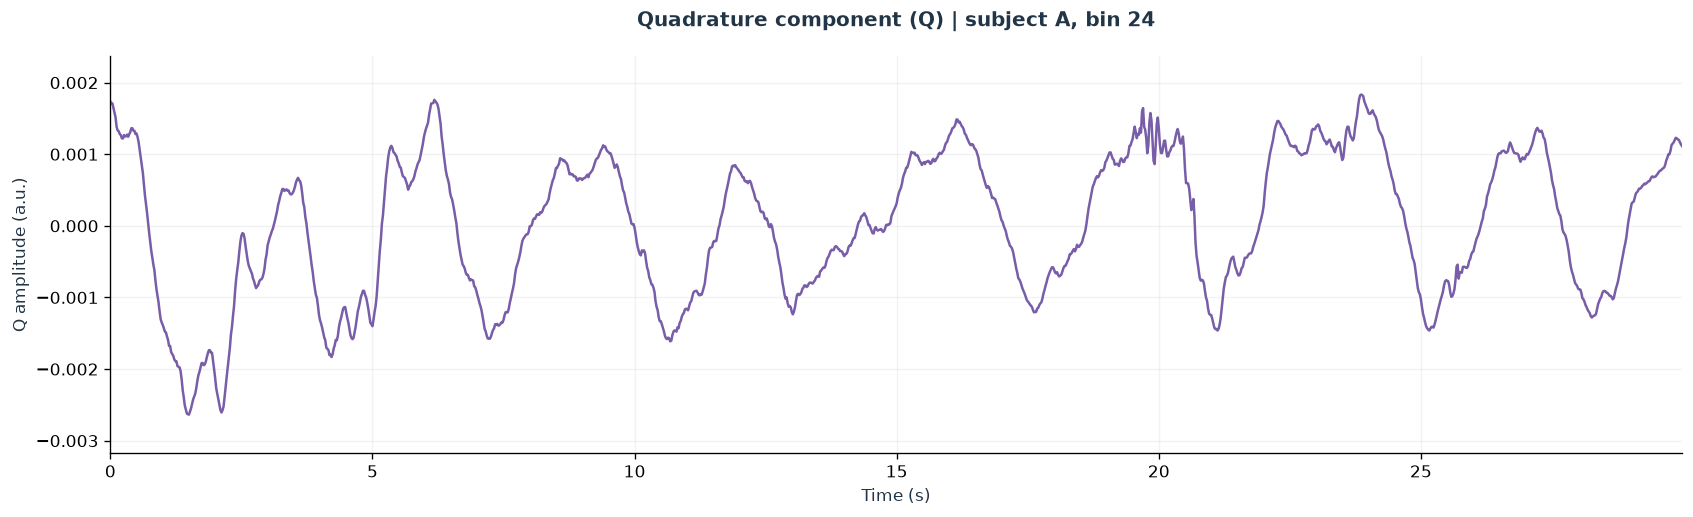

In [9]:
fig, ax = plt.subplots(figsize=(14, 4.2), layout="constrained")
ax.plot(time_s, iq.imag, color=C["test"])
ax.set(title=f"Quadrature component (Q) | subject {SELECTED_SUBJECT}, bin {RANGE_BIN}",
       xlabel="Time (s)", ylabel="Q amplitude (a.u.)")
ax.set_title(ax.get_title(), pad=18)
ax.margins(x=0, y=.12)
figure(fig, "04c_quadrature")

### Combined I/Q measurements
Both components of the same complex radar signal, `z(t) = I(t) + jQ(t)`, are overlaid on a shared time axis and a shared amplitude axis. Original sensor values and offsets are preserved; neither trace is standardized. Blue shows I (real), and purple shows Q (imaginary).

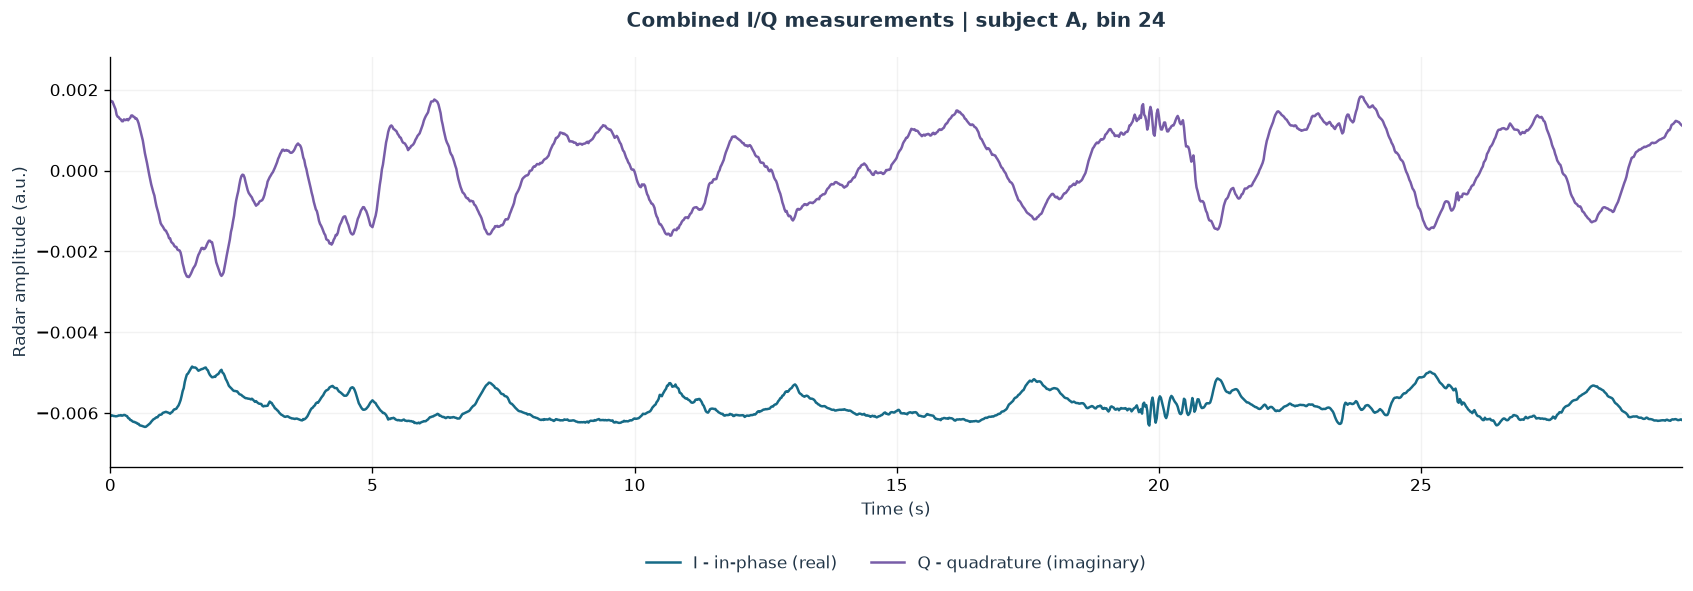

In [10]:
fig, ax = plt.subplots(figsize=(14, 4.8), layout="constrained")
ax.plot(time_s, iq.real, color=C["train"], label="I - in-phase (real)")
ax.plot(time_s, iq.imag, color=C["test"], label="Q - quadrature (imaginary)")
ax.set(title=f"Combined I/Q measurements | subject {SELECTED_SUBJECT}, bin {RANGE_BIN}",
       xlabel="Time (s)", ylabel="Radar amplitude (a.u.)")
ax.set_title(ax.get_title(), pad=18)
ax.margins(x=0, y=.12)
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.18), ncol=2)
figure(fig, "04f_combined_iq")

### 4.4. Magnitude and phase
Magnitude is derived as `sqrt(I**2 + Q**2)`. Unwrapped phase is shown as a separate visualization transform, not as a model prediction.

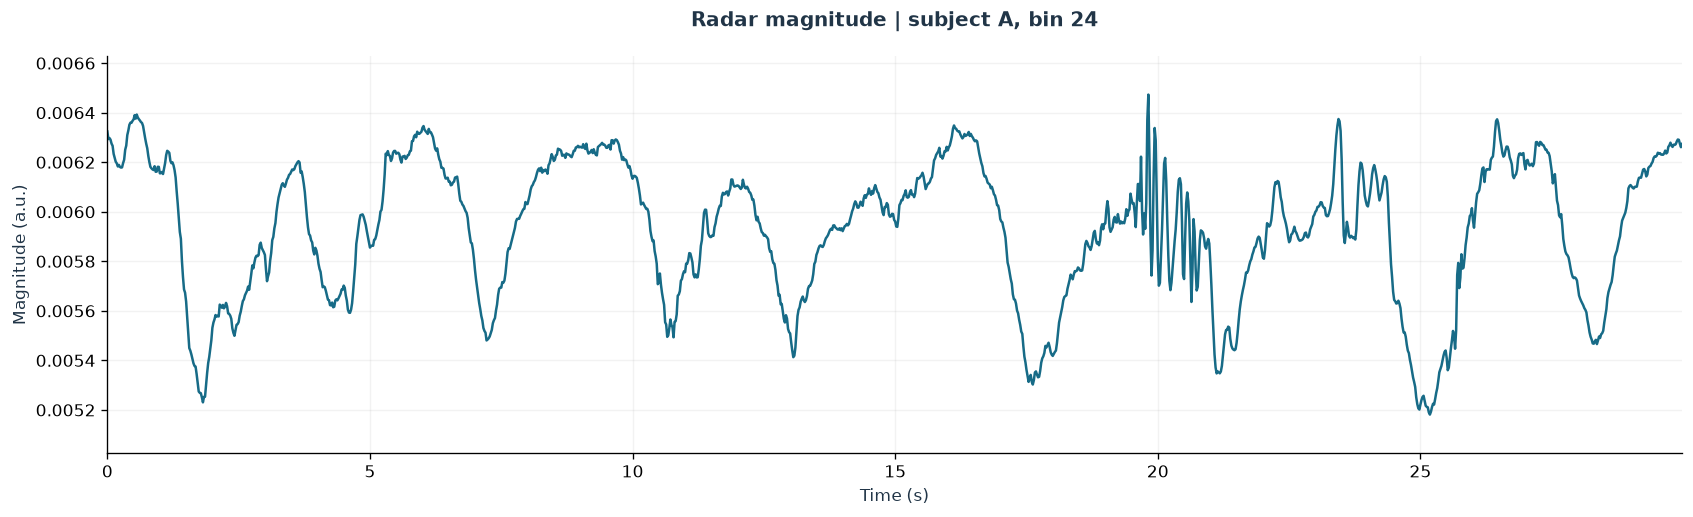

In [11]:
fig, ax = plt.subplots(figsize=(14, 4.2), layout="constrained")
ax.plot(time_s, magnitude, color=C["train"])
ax.set(title=f"Radar magnitude | subject {SELECTED_SUBJECT}, bin {RANGE_BIN}",
       xlabel="Time (s)", ylabel="Magnitude (a.u.)")
ax.set_title(ax.get_title(), pad=18)
ax.margins(x=0, y=.12)
figure(fig, "04d_magnitude")

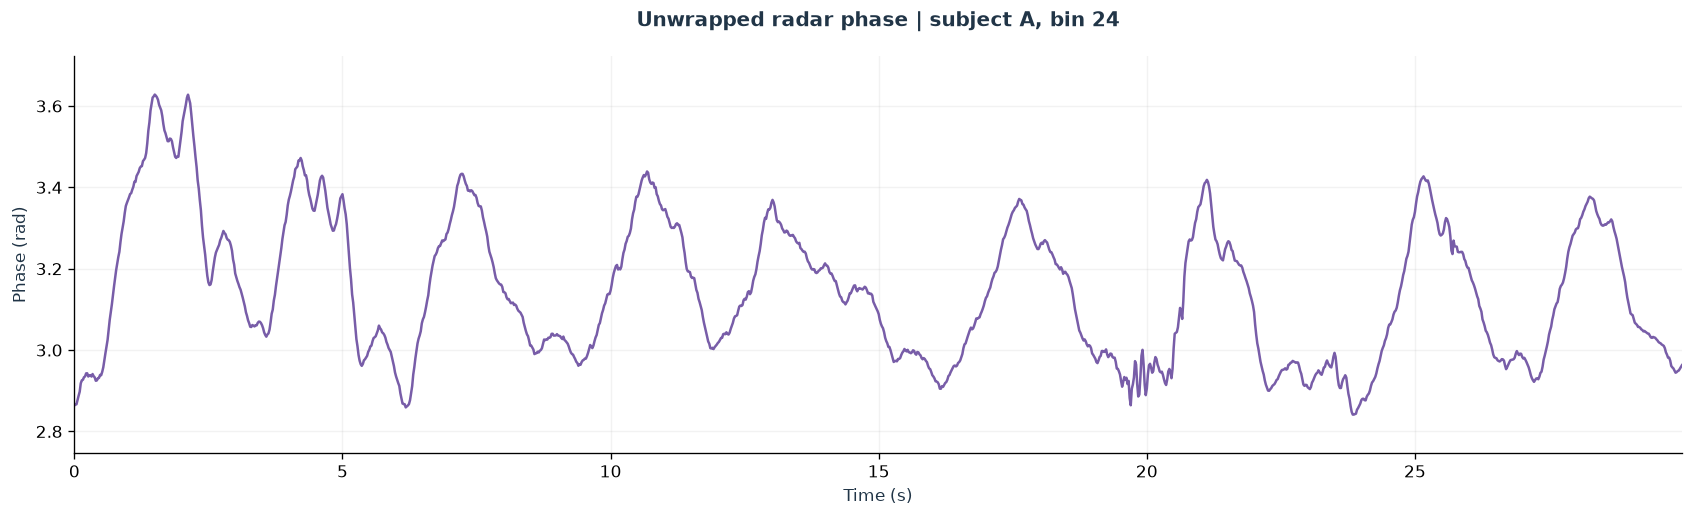

In [12]:
fig, ax = plt.subplots(figsize=(14, 4.2), layout="constrained")
ax.plot(time_s, phase, color=C["test"])
ax.set(title=f"Unwrapped radar phase | subject {SELECTED_SUBJECT}, bin {RANGE_BIN}",
       xlabel="Time (s)", ylabel="Phase (rad)")
ax.set_title(ax.get_title(), pad=18)
ax.margins(x=0, y=.12)
figure(fig, "04e_phase")

### 4.5. Respiration reference and single-window anatomy
The comparison uses independent z-score scaling. The anatomy plot shows one measured 200-sample history and 25-sample target.

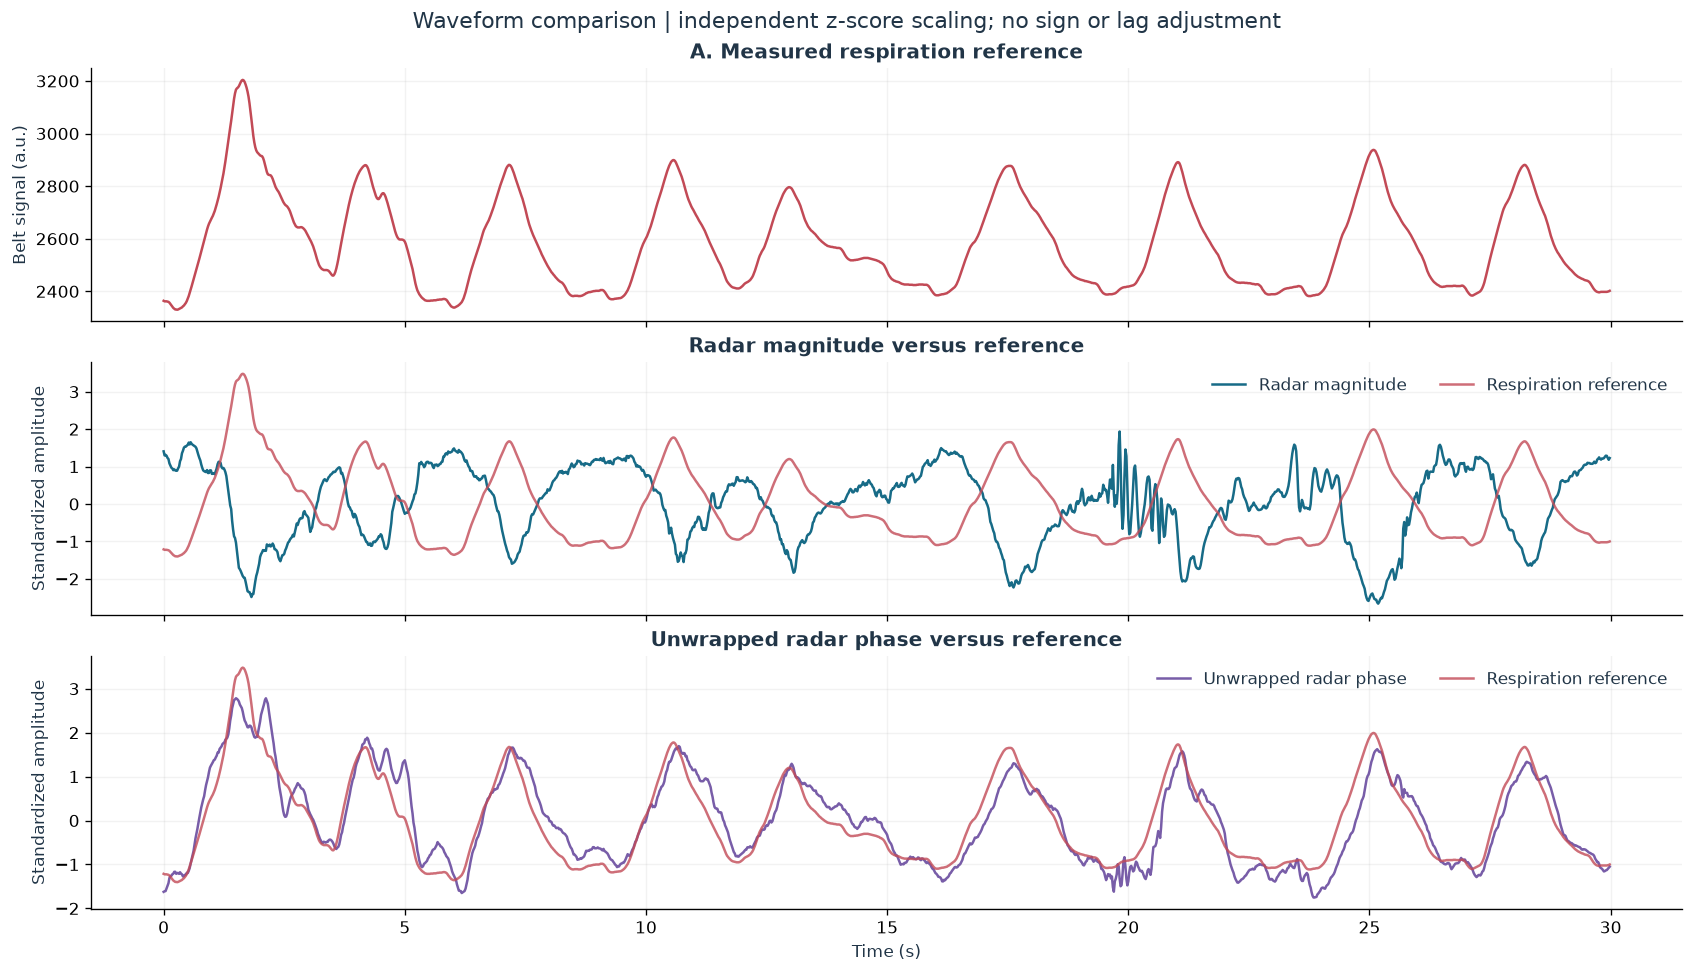

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), constrained_layout=True, sharex=True)
axes[0].plot(time_s,gt,color=C["gt"])
axes[0].set(title="A. Measured respiration reference",ylabel="Belt signal (a.u.)")
for ax, x, label, color in [(axes[1],magnitude,"Radar magnitude",C["train"]),
                            (axes[2],phase,"Unwrapped radar phase",C["test"])]:
    ax.plot(time_s,zscore(x),label=label,color=color)
    ax.plot(time_s,zscore(gt),label="Respiration reference",color=C["gt"],alpha=.8)
    ax.set(title=label + " versus reference",ylabel="Standardized amplitude")
    ax.legend(loc="upper right",ncol=2)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Waveform comparison | independent z-score scaling; no sign or lag adjustment",fontsize=13)
figure(fig,"05_reference_comparison")



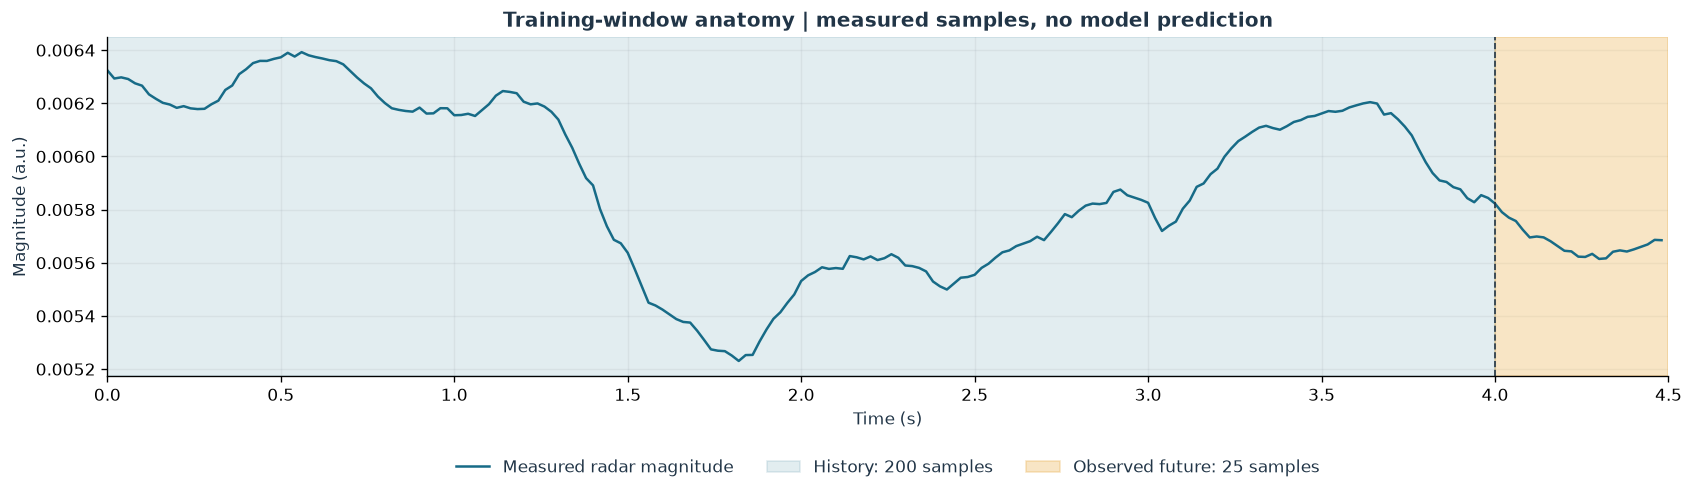

In [14]:
fig, ax = plt.subplots(figsize=(14,4),constrained_layout=True)
ax.plot(time_s[:225],magnitude[:225],color=C["train"],label="Measured radar magnitude")
ax.axvspan(0,200/SAMPLE_RATE_HZ,color=C["train"],alpha=.12,label="History: 200 samples")
ax.axvspan(200/SAMPLE_RATE_HZ,225/SAMPLE_RATE_HZ,color=C["val"],alpha=.3,label="Observed future: 25 samples")
ax.axvline(200/SAMPLE_RATE_HZ,color=C["ink"],ls="--",lw=1)
ax.set(title="Training-window anatomy | measured samples, no model prediction",
       xlabel="Time (s)",ylabel="Magnitude (a.u.)",xlim=(0,225/SAMPLE_RATE_HZ))
ax.legend(loc="upper center",bbox_to_anchor=(.5,-.2),ncol=3)
figure(fig,"06_history_future")


### 4.6. Sliding-window construction
Each example contains **200 history samples** and **25 observed future samples**. Moving the start by **25 samples (0.5 s at 50 Hz)** creates the next example.

Successive history segments overlap by **175 samples (87.5%)**. All windows shown belong to the same recording; this temporal overlap does not change its subject-level train/validation assignment.

The diagram shows the first four windows over one shared measured waveform. Blue denotes the history input and amber denotes the observed target. Labels use zero-based sample indices; Python slice endpoints in the table are exclusive. These windows illustrate the geometry before any ground-truth-based training filter.

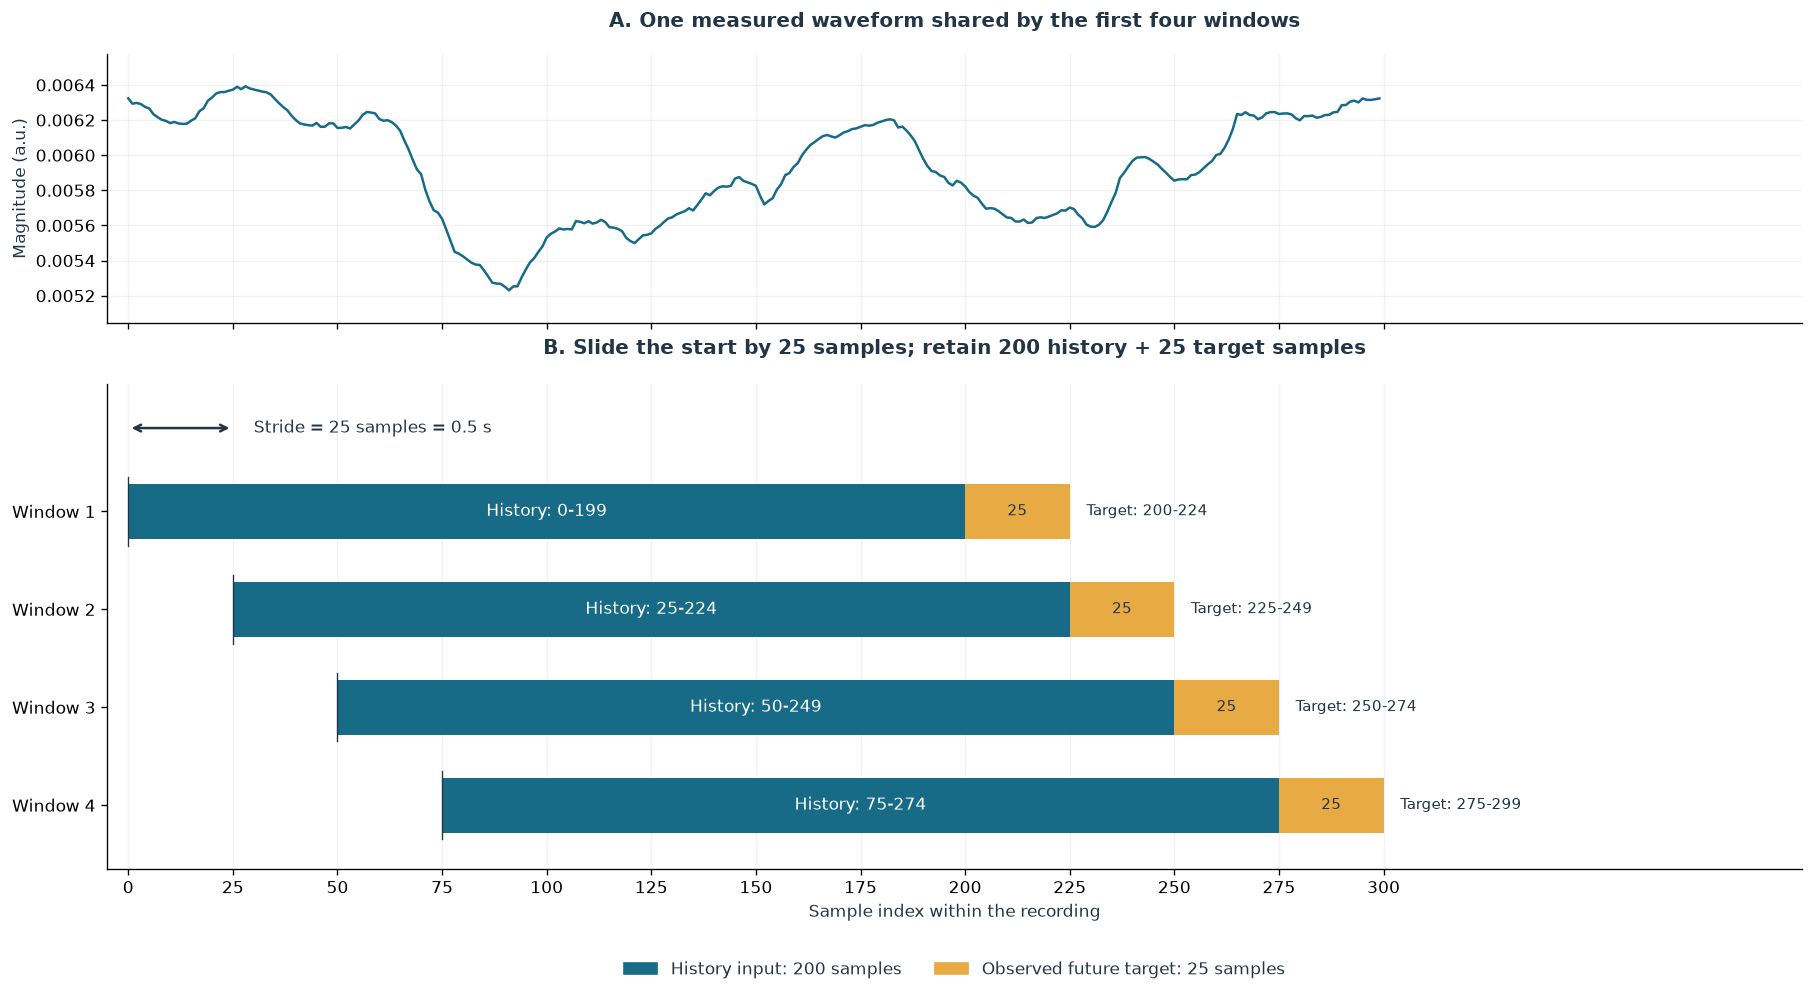

### Table 14. Sliding-window indices and exact slices

| Window | Start sample | History slice X | Target slice y | Start time (s) |
| --- | --- | --- | --- | --- |
| 1 | 0 | [0:200] | [200:225] | 0.00 |
| 2 | 25 | [25:225] | [225:250] | 0.50 |
| 3 | 50 | [50:250] | [250:275] | 1.00 |
| 4 | 75 | [75:275] | [275:300] | 1.50 |
| 52 | 1,275 | [1275:1475] | [1475:1500] | 25.50 |

First four and final window shown. Slice [a:b] includes a and excludes b. All future targets shown are measured samples, not model predictions.

Windows per 1,500-sample candidate: floor((1500 - 200 - 25) / 25) + 1 = 52
Adjacent history overlap: 175 / 200 = 87.5%. Last target: samples 1475 through 1499.


In [15]:
HISTORY, FUTURE, STRIDE = 200, 25, 25
starts = np.arange(0, len(magnitude) - HISTORY - FUTURE + 1, STRIDE)
shown_starts = starts[:4]
visible_end = int(shown_starts[-1] + HISTORY + FUTURE)

fig, axes = plt.subplots(2, 1, figsize=(15, 8.2), layout="constrained",
                         gridspec_kw={"height_ratios": [1, 1.8]}, sharex=True)
axes[0].plot(np.arange(visible_end), magnitude[:visible_end], color=C["train"])
axes[0].set(title="A. One measured waveform shared by the first four windows",
            ylabel="Magnitude (a.u.)")
axes[0].set_title(axes[0].get_title(), pad=16)
axes[0].margins(y=.16)
for i, start in enumerate(shown_starts):
    target_start = int(start + HISTORY)
    target_end = int(target_start + FUTURE)
    axes[1].broken_barh([(int(start), HISTORY)], (i-.28, .56), facecolors=C["train"])
    axes[1].broken_barh([(target_start, FUTURE)], (i-.28, .56), facecolors=C["val"])
    axes[1].text(start + HISTORY/2, i, f"History: {start}-{target_start-1}",
                 ha="center", va="center", color="white", fontsize=10)
    axes[1].text(target_start + FUTURE/2, i, "25",
                 ha="center", va="center", color=C["ink"], fontsize=9)
    axes[1].text(target_end+4, i, f"Target: {target_start}-{target_end-1}",
                 ha="left", va="center", fontsize=9, color=C["ink"])
    axes[1].plot([start,start], [i-.35,i+.35], color=C["ink"], lw=.8)
axes[1].annotate("", xy=(STRIDE,-.85), xytext=(0,-.85),
                 arrowprops={"arrowstyle":"<->","color":C["ink"],"lw":1.5})
axes[1].text(STRIDE+5,-.85,"Stride = 25 samples = 0.5 s",va="center",fontsize=10)
axes[1].set_yticks(range(4), [f"Window {i+1}" for i in range(4)])
axes[1].set(title="B. Slide the start by 25 samples; retain 200 history + 25 target samples",
            xlabel="Sample index within the recording", ylim=(3.65,-1.3), xlim=(-5, visible_end+100))
axes[1].set_title(axes[1].get_title(),pad=18)
axes[1].set_xticks(np.arange(0,visible_end+1,25))
axes[1].grid(axis="y",visible=False)
axes[1].legend(handles=[Patch(color=C["train"],label="History input: 200 samples"),
                        Patch(color=C["val"],label="Observed future target: 25 samples")],
                loc="upper center",bbox_to_anchor=(.5,-.16),ncol=2)
figure(fig,"08_sliding_windows")

selected_indices = [0,1,2,3,len(starts)-1]
table("Sliding-window indices and exact slices",
      ["Window", "Start sample", "History slice X", "Target slice y", "Start time (s)"],
      [[i+1,int(starts[i]),f"[{starts[i]}:{starts[i]+HISTORY}]",
        f"[{starts[i]+HISTORY}:{starts[i]+HISTORY+FUTURE}]",
        f"{starts[i]/SAMPLE_RATE_HZ:.2f}"] for i in selected_indices],
      "First four and final window shown. Slice [a:b] includes a and excludes b. "
      "All future targets shown are measured samples, not model predictions.")
assert len(starts)==52
assert np.all(np.diff(starts)==STRIDE)
assert starts[-1]+HISTORY+FUTURE==len(magnitude)
assert HISTORY-STRIDE==175
print(f"Windows per 1,500-sample candidate: floor((1500 - {HISTORY} - {FUTURE}) / {STRIDE}) + 1 = {len(starts)}")
print("Adjacent history overlap: 175 / 200 = 87.5%. Last target: samples 1475 through 1499.")

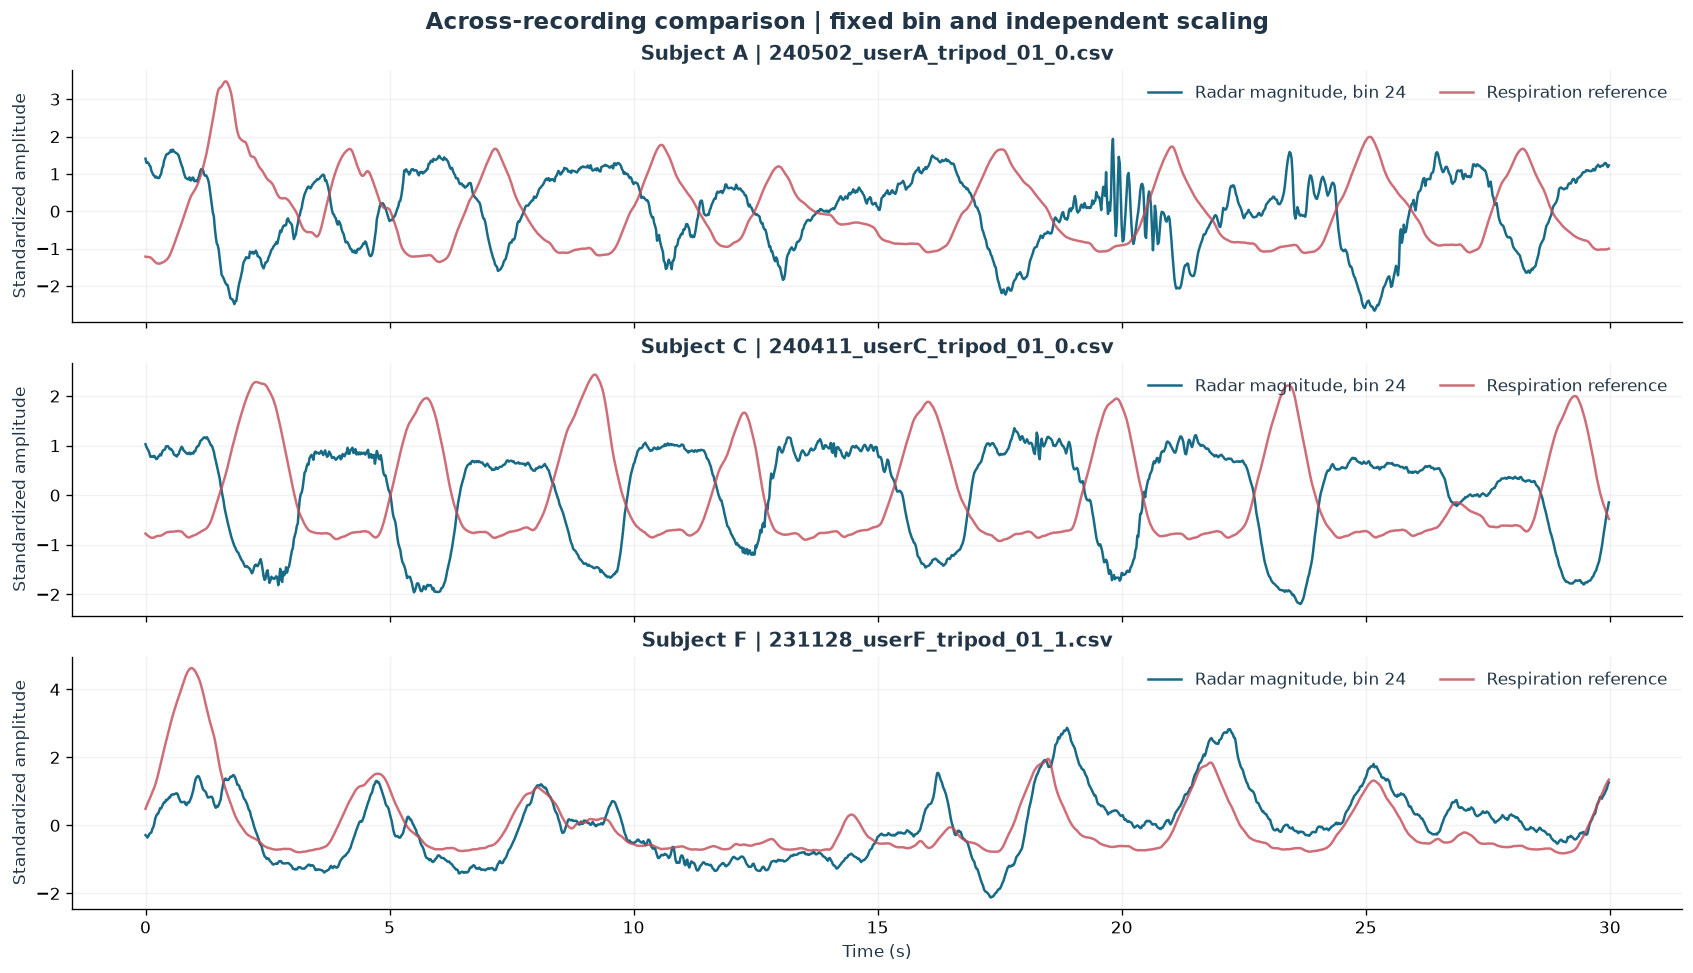

These examples show measured signal variability. A manually fixed bin may contain weak respiratory content. The plots do not establish model accuracy, select a configuration, or evaluate the held-out test set.

In [16]:
fig, axes = plt.subplots(len(recordings),1,figsize=(14,8),sharex=True,constrained_layout=True)
for ax,(u,r) in zip(axes,recordings.items()):
    x=np.abs(r["radar"][:,RANGE_BIN])
    ax.plot(time_s,zscore(x),color=C["train"],label=f"Radar magnitude, bin {RANGE_BIN}")
    ax.plot(time_s,zscore(r["gt"]),color=C["gt"],alpha=.8,label="Respiration reference")
    ax.set(title=f"Subject {u} | {r['name']}",ylabel="Standardized amplitude")
    ax.legend(loc="upper right",ncol=2)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Across-recording comparison | fixed bin and independent scaling",fontsize=14,fontweight="bold")
figure(fig,"07_subject_comparison")
display(Markdown("These examples show measured signal variability. A manually fixed bin may contain weak respiratory content. "
                 "The plots do not establish model accuracy, select a configuration, or evaluate the held-out test set."))


## 5. Verification
The checks below verify documented totals, subject separation, and the availability of three complete real recordings. Model training, model inference, and full-dataset revalidation are outside this report.


In [17]:
assert total_sessions == 1826 and total_windows == 292708
assert sum(sessions[u] for u in DEV_USERS)==1289
assert sum(sessions[u] for u in TEST_USERS)==537
assert sorted(u for f in plan["folds"] for u in f["validation"])==sorted(DEV_USERS)
for f in plan["folds"]:
    assert not set(f["train"]) & set(f["validation"])
    assert not set(f["train"]+f["validation"]) & set(TEST_USERS)
assert nw == [210964,218920,230152,218088]
assert set(recordings)==set("ACF")
assert table_count==14
print("PASS | documented totals and all four subject-disjoint folds")
print("PASS | three real recordings: A, C, F; checksums and finite samples verified")
print(f"COMPLETE | {table_count} tables and thirteen figures")
print("Inventory source: project documentation. Waveform source: public MobiVital measurements.")


PASS | documented totals and all four subject-disjoint folds
PASS | three real recordings: A, C, F; checksums and finite samples verified
COMPLETE | 14 tables and thirteen figures
Inventory source: project documentation. Waveform source: public MobiVital measurements.
